# State load generation

This notebook applies TELL's forward-execution method after BA hourly forecasts already exist. A worked Iowa example uses 2039 weather/load and one GCAM demand case, then compares the result with the packaged state-load archive. The final section shows all nine archived Iowa annual load trajectories for 2000-2099.

**Inputs:** Packaged TaiESM1 BA and Iowa load, BA service territories, fixed 2020 county population, and GCAM-USA electricity demand. The installed TELL package performs the county allocation and state scaling.

**Requirements:** The repository environment with TELL and bundled inputs. The example runs TELL's state allocation and scaling locally; BA model training is already complete.

**Outputs:** TELL-compatible scratch inputs and modeled load under `../../data_outputs/data_flow/state_load_generation/`, an archive comparison, and load plots. These scratch files adapt layout and column names for this example; downstream analysis uses the packaged state-load Parquet.

Run the code cells from top to bottom. See the [setup instructions](../../README.md#quick-start).


## Setup

Step 1 selects the bundled Iowa example: 2039 BA load and the `rcp85hotter_ssp5` demand case.


In [1]:
import os
import shutil
import warnings
from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="pkg_resources is deprecated as an API.*", category=UserWarning)
    import tell

pd.options.display.max_columns = 80

# Shared presentation defaults; data values and plot limits are set below.
plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "normal",
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "legend.frameon": False,
        "grid.color": "#d1d5db",
        "grid.linewidth": 0.7,
        "grid.alpha": 0.65,
        "figure.titlesize": 16,
        "figure.titleweight": "bold",
    }
)

## Step 1: Locate packaged inputs

This section defines paths and checks the bundled version `0.1.0` inputs under `data_inputs/examples/`. The three BA files contain 2039 only; the Iowa state-load Parquet retains all 2000–2099 hours and all nine load cases. No archive extraction is needed.

The manifest identifies the archived inputs before the TELL scratch files are created.

For another state or BA-load year, obtain the required inputs from the full archive and update the paths. To change the GCAM demand case, update both `scenario_to_process` and the explicit `gcam_usa_source_path` below.

In [2]:
# Fixed Iowa example: 2039 weather/load and the selected GCAM demand case.
STATE_NAME = "Iowa"
year_to_process = "2039"
gcam_target_year = "2039"
scenario_to_process = "rcp85hotter_ssp5"

BA_LOAD_INPUTS = {
    "AECI": Path("../../data_inputs/examples/taiesm1_historical_ssp245_v022_2000_2099/ba_load/AECI_taiesm1_historical_ssp245_v022_2000_2099_load.csv.gz"),
    "MISO_0035": Path("../../data_inputs/examples/taiesm1_historical_ssp245_v022_2000_2099/ba_load/MISO_0035_taiesm1_historical_ssp245_v022_2000_2099_load.csv.gz"),
    "SWPP": Path("../../data_inputs/examples/taiesm1_historical_ssp245_v022_2000_2099/ba_load/SWPP_taiesm1_historical_ssp245_v022_2000_2099_load.csv.gz"),
}
state_load_path = Path("../../data_inputs/examples/taiesm1_historical_ssp245_v022_2000_2099/state_load/IA_taiesm1_historical_ssp245_v022_2000_2099_load.parquet")
ba_mapping_path = Path("../../data_inputs/county_weather/ba_service_territory_2019.csv")
county_population_path = Path("../../data_inputs/county_weather/county_populations_2000_to_2020.csv")
gcam_usa_source_path = Path("../../data_inputs/gcam_usa/electricity_demand_rcp85hotter_ssp5.csv")
OUTPUT_DIR = Path("../../data_outputs/data_flow/state_load_generation")
# Resolve the TELL scratch directory to avoid Windows relative-path length limits.
tell_data_dir = (OUTPUT_DIR / "tell_data").resolve()
tell_image_dir = tell_data_dir / "visualizations"

input_rows = []
for ba, path in BA_LOAD_INPUTS.items():
    input_rows.append((f"{ba} hourly load", path))
input_rows.extend(
    [
        ("Iowa state load", state_load_path),
        ("BA service territories", ba_mapping_path),
        ("County population", county_population_path),
        ("Selected GCAM demand", gcam_usa_source_path),
    ]
)
input_manifest = pd.DataFrame(input_rows, columns=["input", "path"])
input_manifest["exists"] = input_manifest["path"].map(lambda path: path.is_file())
if not input_manifest["exists"].all():
    missing = input_manifest.loc[~input_manifest["exists"], "path"].map(lambda path: path.as_posix())
    raise FileNotFoundError("Missing required notebook inputs:\n" + "\n".join(missing))
input_manifest["path"] = input_manifest["path"].map(lambda path: path.as_posix())
with pd.option_context("display.max_colwidth", None):
    preview = input_manifest
    preview = preview.rename(columns={"input": "Input", "path": "Path", "exists": "Exists"})
    preview = preview.style.hide(axis="index")
    display(preview)

Input,Path,Exists
AECI hourly load,../../data_inputs/examples/taiesm1_historical_ssp245_v022_2000_2099/ba_load/AECI_taiesm1_historical_ssp245_v022_2000_2099_load.csv.gz,True
MISO_0035 hourly load,../../data_inputs/examples/taiesm1_historical_ssp245_v022_2000_2099/ba_load/MISO_0035_taiesm1_historical_ssp245_v022_2000_2099_load.csv.gz,True
SWPP hourly load,../../data_inputs/examples/taiesm1_historical_ssp245_v022_2000_2099/ba_load/SWPP_taiesm1_historical_ssp245_v022_2000_2099_load.csv.gz,True
Iowa state load,../../data_inputs/examples/taiesm1_historical_ssp245_v022_2000_2099/state_load/IA_taiesm1_historical_ssp245_v022_2000_2099_load.parquet,True
BA service territories,../../data_inputs/county_weather/ba_service_territory_2019.csv,True
County population,../../data_inputs/county_weather/county_populations_2000_to_2020.csv,True
Selected GCAM demand,../../data_inputs/gcam_usa/electricity_demand_rcp85hotter_ssp5.csv,True


## Step 2: Prepare TELL-compatible scratch inputs

`tell.execute_forward(...)` expects the quickstarter-style directory layout. The following stages create that layout under `data_outputs/`, then copy or reshape the packaged `wxdata` inputs into that layout.

This is intentionally a staging step. The methodology remains the TELL forward-execution method:

```text
BA hourly load -> county population allocation -> state hourly load -> GCAM-USA scaling
```

### Create the TELL-style scratch folders

This creates empty folders with the same roles as the TELL quickstarter inputs: service-territory mapping, MLP load outputs, GCAM-USA forcing, population projections, and TELL output.

In [3]:
# Create the TELL quickstarter-like folder layout used by tell.execute_forward:
tell_quickstarter_dir = tell_data_dir / "tell_quickstarter_data"
sample_forcing_dir = tell_data_dir / "sample_forcing_data"

data_output_dir = tell_quickstarter_dir / "outputs" / "tell_output"
map_input_dir = tell_quickstarter_dir / "outputs" / "ba_service_territory"
mlp_input_dir = tell_quickstarter_dir / "outputs" / "mlp_output"
gcam_usa_input_dir = sample_forcing_dir / "sample_gcam_usa_data"
pop_input_dir = sample_forcing_dir / "sample_population_projections"

for path in [
    data_output_dir,
    map_input_dir,
    mlp_input_dir,
    gcam_usa_input_dir,
    pop_input_dir,
    tell_image_dir,
]:
    path.mkdir(parents=True, exist_ok=True)

### Stage service territories and fixed population

Iowa receives load from AECI, MISO_0035 and SWPP. Keep every county served by those contributors, including counties outside Iowa, so each BA allocation uses its full population denominator. Read `pop_2020` once and repeat it across the 2000-2099 columns required by TELL; no separate century-long population input is needed.

In [4]:
# Keep every county served by the three BAs that contribute to Iowa.
full_ba_mapping_df = pd.read_csv(ba_mapping_path)
ba_mapping_df = full_ba_mapping_df[full_ba_mapping_df["BA_Code"].isin(BA_LOAD_INPUTS)].copy()
missing_mapping_bas = sorted(set(BA_LOAD_INPUTS) - set(ba_mapping_df["BA_Code"]))
if missing_mapping_bas:
    raise AssertionError(f"Missing service-territory rows for Iowa contributor BAs: {missing_mapping_bas}")
ba_mapping_df.to_csv(map_input_dir / "ba_service_territory_2019.csv", index=False)

# Stage static 2020 population as TELL-shaped SSP population files.
county_population = pd.read_csv(county_population_path, usecols=["county_FIPS", "pop_2020"])
county_state_df = full_ba_mapping_df[["County_FIPS", "State_Name"]].drop_duplicates("County_FIPS")
population_by_year = {}
for year in range(2000, 2100):
    population_by_year[year] = county_population["pop_2020"].to_numpy()

population_wide = pd.DataFrame(
    population_by_year,
    index=county_population["county_FIPS"],
)
population_wide = population_wide.rename_axis("County_FIPS")
population_wide = population_wide.sort_index()
population_wide = population_wide.reset_index()
population_wide = population_wide.merge(county_state_df, on="County_FIPS", how="left")
population_wide["State_Name"] = population_wide["State_Name"].fillna("Unused")
year_columns = [column for column in population_wide.columns if isinstance(column, int)]
population_wide = population_wide.rename(columns={"County_FIPS": "FIPS", "State_Name": "state_name"})
population_wide = population_wide[["FIPS", "state_name", *year_columns]]
for ssp in ["ssp3", "ssp5"]:
    population_wide.to_csv(pop_input_dir / f"{ssp}_county_population.csv", index=False)

### Stage GCAM-USA demand and one year of BA load

The GCAM-USA file selected by `scenario_to_process` is copied into the TELL-style forcing folder. The BA load files are filtered to the example year and renamed into TELL's `mlp_output` shape.

This notebook stages one example year because the goal is to mirror TELL's forward-execution call for a reviewer. The operational state builder creates the full 2000-2099 archived state-load products.

In [5]:
# Stage the GCAM-USA file selected for this example.
if not gcam_usa_source_path.exists():
    raise FileNotFoundError(f"Missing GCAM-USA input: {gcam_usa_source_path.as_posix()}")
gcam_usa_staged_path = gcam_usa_input_dir / gcam_usa_source_path.name
shutil.copy2(gcam_usa_source_path, gcam_usa_staged_path)

# Stage BA load projections in TELL's mlp_output shape:
mlp_year_dir = mlp_input_dir / scenario_to_process / year_to_process
mlp_year_dir.mkdir(parents=True, exist_ok=True)
staged_ba_codes = []
for ba_code, source_path in BA_LOAD_INPUTS.items():
    if not source_path.exists():
        raise FileNotFoundError(f"Missing {year_to_process} BA load input for Iowa contributor BA: {source_path.as_posix()}")
    frame = pd.read_csv(source_path, parse_dates=["time_utc"])
    frame = frame[frame["time_utc"].dt.year.eq(int(year_to_process))].copy()
    frame = frame.rename(columns={"time_utc": "Time_UTC", "load_mw": "Load"})
    frame["BA"] = ba_code
    frame[["Time_UTC", "Load", "BA"]].to_csv(mlp_year_dir / f"{ba_code}_{year_to_process}_mlp_output.csv", index=False)
    staged_ba_codes.append(ba_code)

### Review the staged scratch inputs

This manifest is the checkpoint before calling TELL. If the counts look wrong, the problem is in staging, not in `tell.execute_forward(...)`.

In [6]:
staging_manifest = pd.DataFrame(
    {
        "check": [
            "contributor_ba_codes",
            "service_territory_membership_rows",
            "unique_counties_across_contributor_bas",
            "population_ssp3_file",
            "population_ssp5_file",
            "gcam_usa_file",
            "mlp_output_files",
        ],
        "value": [
            ", ".join(sorted(staged_ba_codes)),
            len(ba_mapping_df),
            ba_mapping_df["County_FIPS"].nunique(),
            (pop_input_dir / "ssp3_county_population.csv").exists(),
            (pop_input_dir / "ssp5_county_population.csv").exists(),
            gcam_usa_staged_path.name,
            len(staged_ba_codes),
        ],
    }
)
preview = staging_manifest
preview = preview.replace(
    {
        "check": {
            "contributor_ba_codes": "Contributor BAs",
            "service_territory_membership_rows": "Service-territory membership rows",
            "unique_counties_across_contributor_bas": "Unique contributor counties",
            "population_ssp3_file": "SSP3 population file exists",
            "population_ssp5_file": "SSP5 population file exists",
            "gcam_usa_file": "GCAM-USA file",
            "mlp_output_files": "BA forecast files",
        }
    }
)
preview = preview.rename(columns={"check": "Check", "value": "Value"})
preview = preview.style.hide(axis="index")
display(preview)

Check,Value
Contributor BAs,"AECI, MISO_0035, SWPP"
Service-territory membership rows,964
Unique contributor counties,771
SSP3 population file exists,True
SSP5 population file exists,True
GCAM-USA file,electricity_demand_rcp85hotter_ssp5.csv
BA forecast files,3


## Step 3: Run the state-load model

This is the required offline TELL forward-execution step. The upstream MLP training step has already been handled by the wxdata BA load workflow and is intentionally not repeated here. Every code cell in this section reads the packaged or staged local inputs.


In [7]:
summary_df, _, state_time_series_df = tell.execute_forward(year_to_process=year_to_process, gcam_target_year=gcam_target_year, scenario_to_process=scenario_to_process, data_output_dir=str(data_output_dir), gcam_usa_input_dir=str(gcam_usa_input_dir), map_input_dir=str(map_input_dir), mlp_input_dir=str(mlp_input_dir), pop_input_dir=str(pop_input_dir), save_county_data=False)

# Select and normalize the Iowa result once for the preview and archive comparison.
iowa_tell = state_time_series_df.loc[state_time_series_df["State_Name"].eq(STATE_NAME), ["Time_UTC", "Raw_TELL_State_Load_MWh", "Scaled_TELL_State_Load_MWh"]].copy()
iowa_tell["Time_UTC"] = pd.to_datetime(iowa_tell["Time_UTC"], utc=True)

Scenario =  rcp85hotter_ssp5 , Year =  2039


Elapsed time =  0:00:13.127085


### Display: Iowa load results

In [8]:
preview = summary_df
preview = preview[summary_df["State_Name"].eq(STATE_NAME)]
preview = preview.rename(
    columns={
        "State_Name": "State",
        "State_FIPS": "State FIPS",
        "Scaling_Factor": "Scaling factor",
        "GCAM_USA_Load_TWh": "GCAM-USA load (TWh)",
        "Raw_TELL_Load_TWh": "Raw TELL load (TWh)",
        "Scaled_TELL_Load_TWh": "Scaled TELL load (TWh)",
    }
)
preview = preview.style.hide(axis="index")
preview = preview.format(
    {
        "State FIPS": "{:.0f}",
        "Scaling factor": "{:.3f}",
        "GCAM-USA load (TWh)": "{:,.3f}",
        "Raw TELL load (TWh)": "{:,.3f}",
        "Scaled TELL load (TWh)": "{:,.3f}",
    }
)
display(preview)
print(f"Iowa sample hours: January 1, {year_to_process} at 00:00, 06:00, 12:00, and 18:00 UTC")
preview = iowa_tell
preview = preview.loc[iowa_tell["Time_UTC"].isin(pd.date_range(f"{year_to_process}-01-01", periods=4, freq="6h", tz="UTC"))]
preview = preview.set_index("Time_UTC")
preview = preview.rename_axis("Time (UTC)")
preview = preview.rename(
    columns={
        "Raw_TELL_State_Load_MWh": "Raw hourly load (MWh)",
        "Scaled_TELL_State_Load_MWh": "Scaled hourly load (MWh)",
    }
)
preview = preview.style.format("{:,.1f}")
display(preview)

Year,State,State FIPS,Scaling factor,GCAM-USA load (TWh),Raw TELL load (TWh),Scaled TELL load (TWh)
2039,Iowa,19000,1.284,64.804,50.454,64.804


Iowa sample hours: January 1, 2039 at 00:00, 06:00, 12:00, and 18:00 UTC


,Raw hourly load (MWh),Scaled hourly load (MWh)
Time (UTC),,
2039-01-01 00:00:00+00:00,"5,705.5","7,328.2"
2039-01-01 06:00:00+00:00,"5,323.5","6,837.5"
2039-01-01 12:00:00+00:00,"5,209.1","6,690.5"
2039-01-01 18:00:00+00:00,"5,715.7","7,341.3"


### Compare with the packaged Iowa archive


In [9]:
packaged_load_df = pd.read_parquet(state_load_path)
packaged_load_df["time_utc"] = pd.to_datetime(packaged_load_df["time_utc"], utc=True)
packaged_example_year = packaged_load_df.loc[packaged_load_df["time_utc"].dt.year.eq(int(year_to_process)), ["time_utc", "load_mw__raw", f"load_mw__gcam_{scenario_to_process}"]].copy()

if iowa_tell["Time_UTC"].duplicated().any() or packaged_example_year["time_utc"].duplicated().any():
    raise AssertionError("TELL or packaged Iowa timestamps are not unique.")

comparison = iowa_tell.merge(packaged_example_year, left_on="Time_UTC", right_on="time_utc", validate="one_to_one")
if len(comparison) != len(iowa_tell) or len(comparison) != len(packaged_example_year):
    raise AssertionError("TELL and packaged Iowa timestamps do not align one-to-one.")

rounding_tolerance_mw = 0.0051
comparison_df = pd.DataFrame(
    {
        "load_case": ["raw", "scaled"],
        "max_abs_diff_mw": [
            (comparison["Raw_TELL_State_Load_MWh"] - comparison["load_mw__raw"]).abs().max(),
            (comparison["Scaled_TELL_State_Load_MWh"] - comparison[f"load_mw__gcam_{scenario_to_process}"]).abs().max(),
        ],
    }
)
if not comparison_df["max_abs_diff_mw"].le(rounding_tolerance_mw).all():
    raise AssertionError("TELL output differs from the packaged Iowa load beyond rounding tolerance.")

print(f"Compared {len(comparison):,} hourly rows; rounding tolerance: {rounding_tolerance_mw} MW.")

Compared 8,760 hourly rows; rounding tolerance: 0.0051 MW.


### Display: Archive comparison

In [10]:
preview = comparison_df
preview = preview.replace({"load_case": {"raw": "Raw", "scaled": "Scaled"}})
preview = preview.rename(columns={"load_case": "Load case", "max_abs_diff_mw": "Maximum absolute difference (MW)"})
preview = preview.style.hide(axis="index")
preview = preview.format({"Maximum absolute difference (MW)": "{:.9e}"})
display(preview)

Load case,Maximum absolute difference (MW)
Raw,4.998824368e-03
Scaled,4.997514806e-03


## Step 4: Plot state and BA load

### Plot the state annual total loads from GCAM-USA and TELL

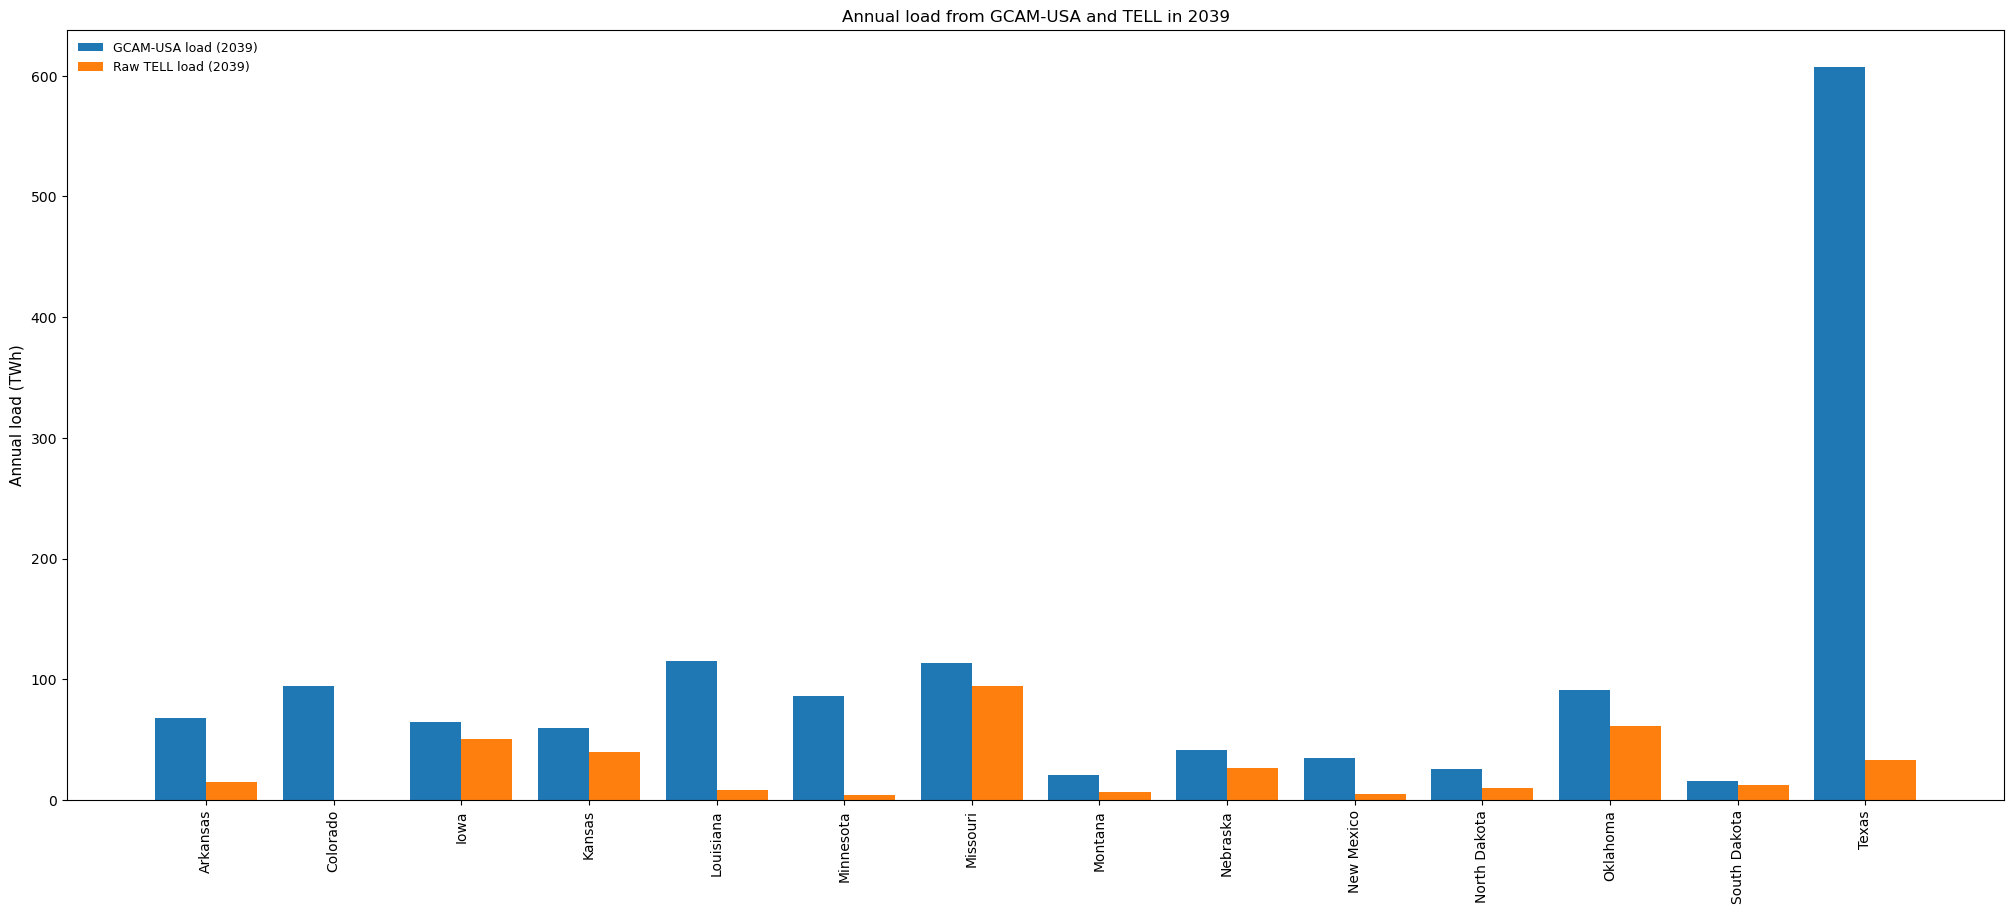

In [11]:
tell.plot_state_annual_total_loads(year_to_plot=year_to_process, gcam_target_year=gcam_target_year, scenario_to_plot=scenario_to_process, data_input_dir=tell_data_dir, image_output_dir=tell_image_dir, image_resolution=150, save_images=False)

ax = plt.gca()
ax.set_title(f"Annual load from GCAM-USA and TELL in {year_to_process}")
ax.set_ylabel("Annual load (TWh)")
ax.legend(labels=[f"GCAM-USA load ({gcam_target_year})", f"Raw TELL load ({year_to_process})"])
plt.show()

### Plot Iowa hourly load

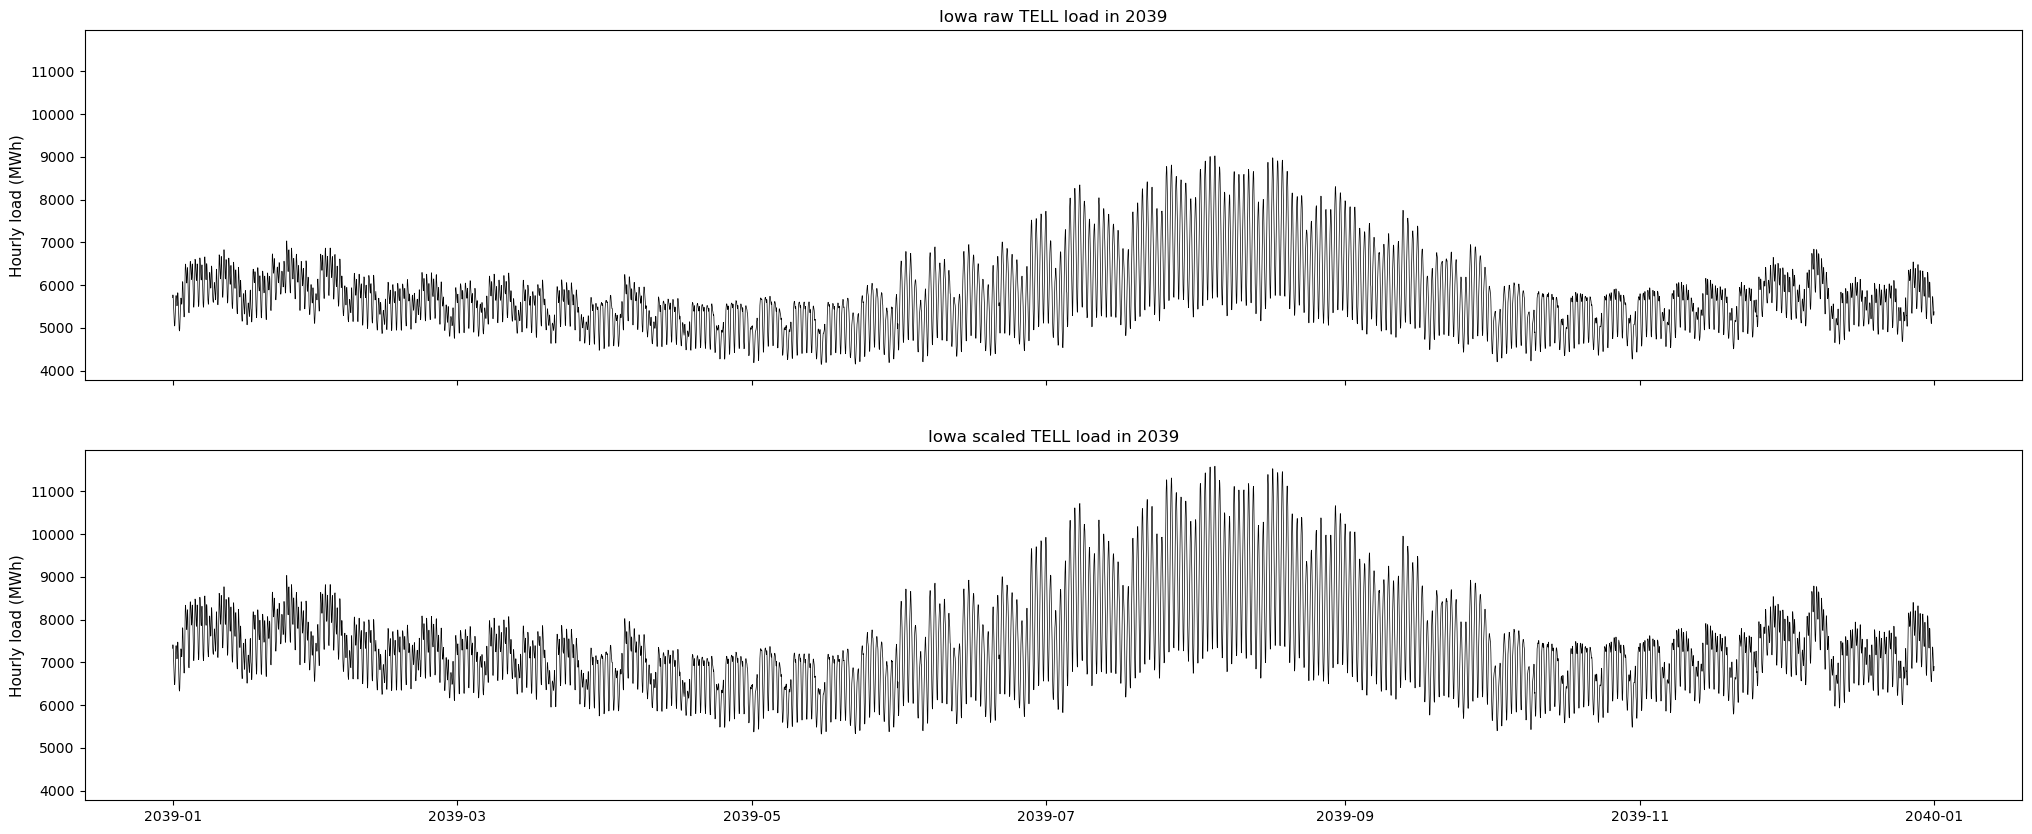

In [12]:
tell.plot_state_load_time_series(state_to_plot=STATE_NAME, year_to_plot=year_to_process, gcam_target_year=gcam_target_year, scenario_to_plot=scenario_to_process, data_input_dir=tell_data_dir, image_output_dir=tell_image_dir, image_resolution=150, save_images=False)

for ax, load_kind in zip(plt.gcf().axes, ["raw", "scaled"]):
    ax.set_title(f"{STATE_NAME} {load_kind} TELL load in {year_to_process}", fontsize=12)
    ax.set_ylabel("Hourly load (MWh)")
plt.show()

### Plot Iowa load duration

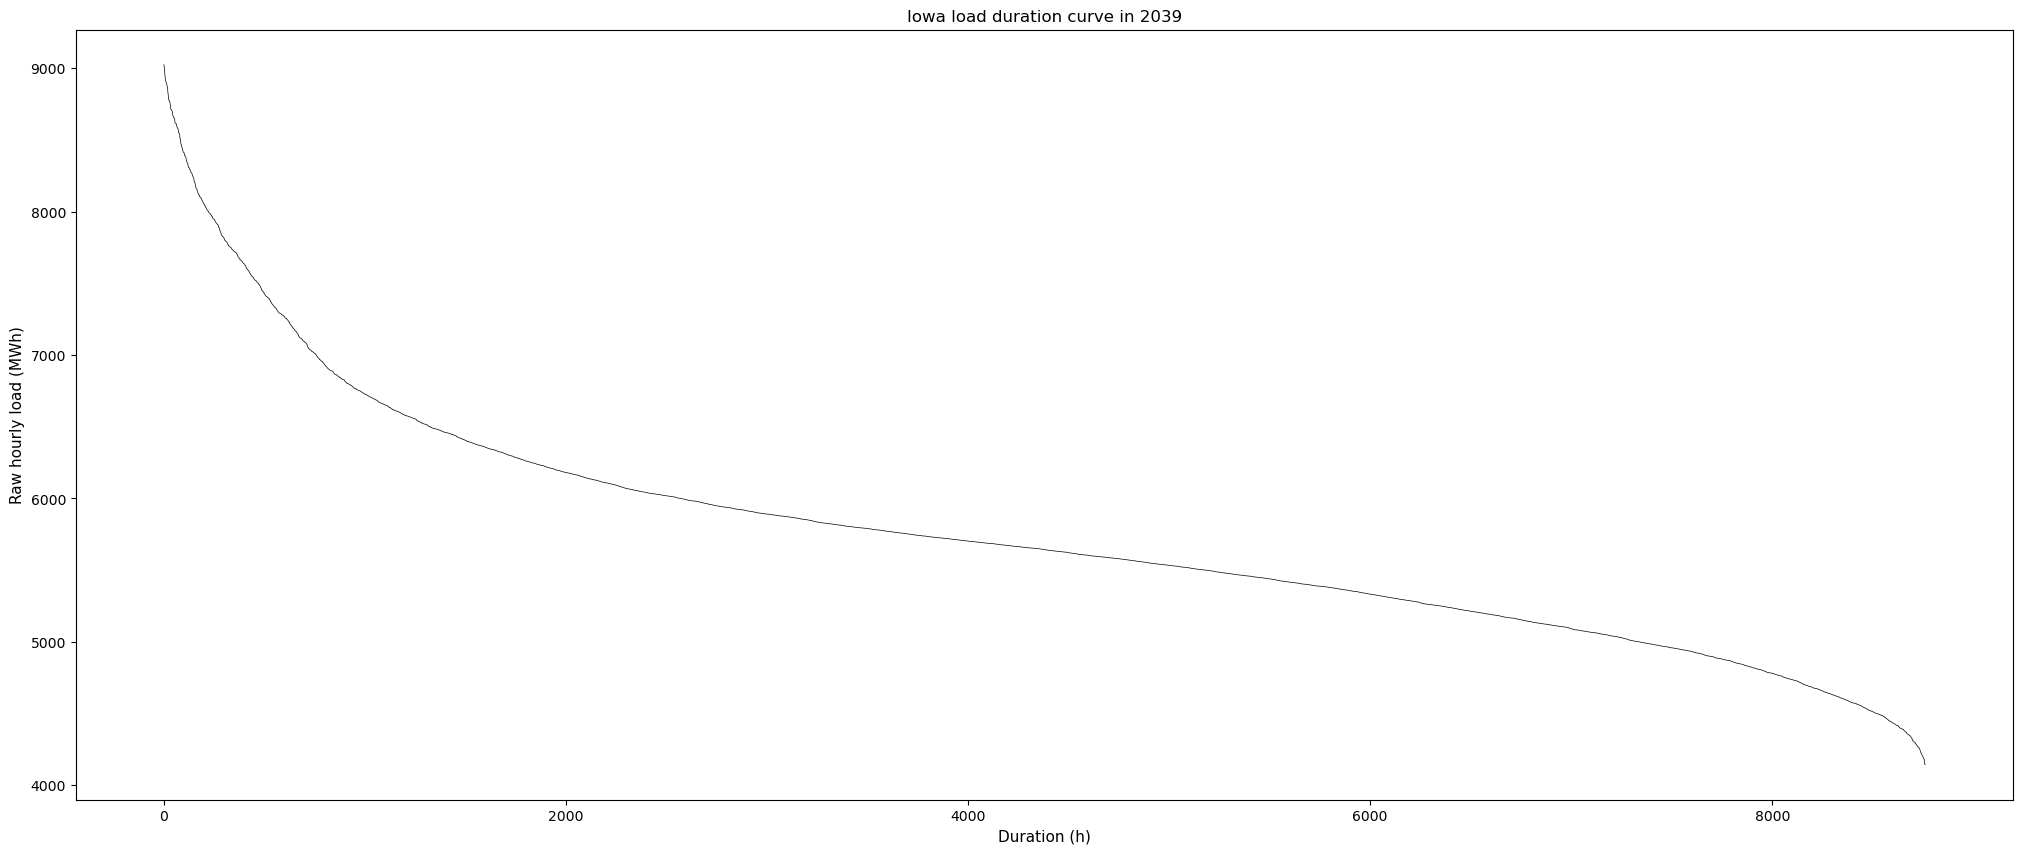

In [13]:
tell.plot_state_load_duration_curve(state_to_plot=STATE_NAME, year_to_plot=year_to_process, gcam_target_year=gcam_target_year, scenario_to_plot=scenario_to_process, data_input_dir=tell_data_dir, image_output_dir=tell_image_dir, image_resolution=150, save_images=False)

ax = plt.gca()
ax.set_title(f"{STATE_NAME} load duration curve in {year_to_process}")
ax.set_xlabel("Duration (h)")
# TELL plots raw load here, despite its original scaled-load axis label.
ax.set_ylabel("Raw hourly load (MWh)")
plt.show()

### Plot the contributing BA's hourly load

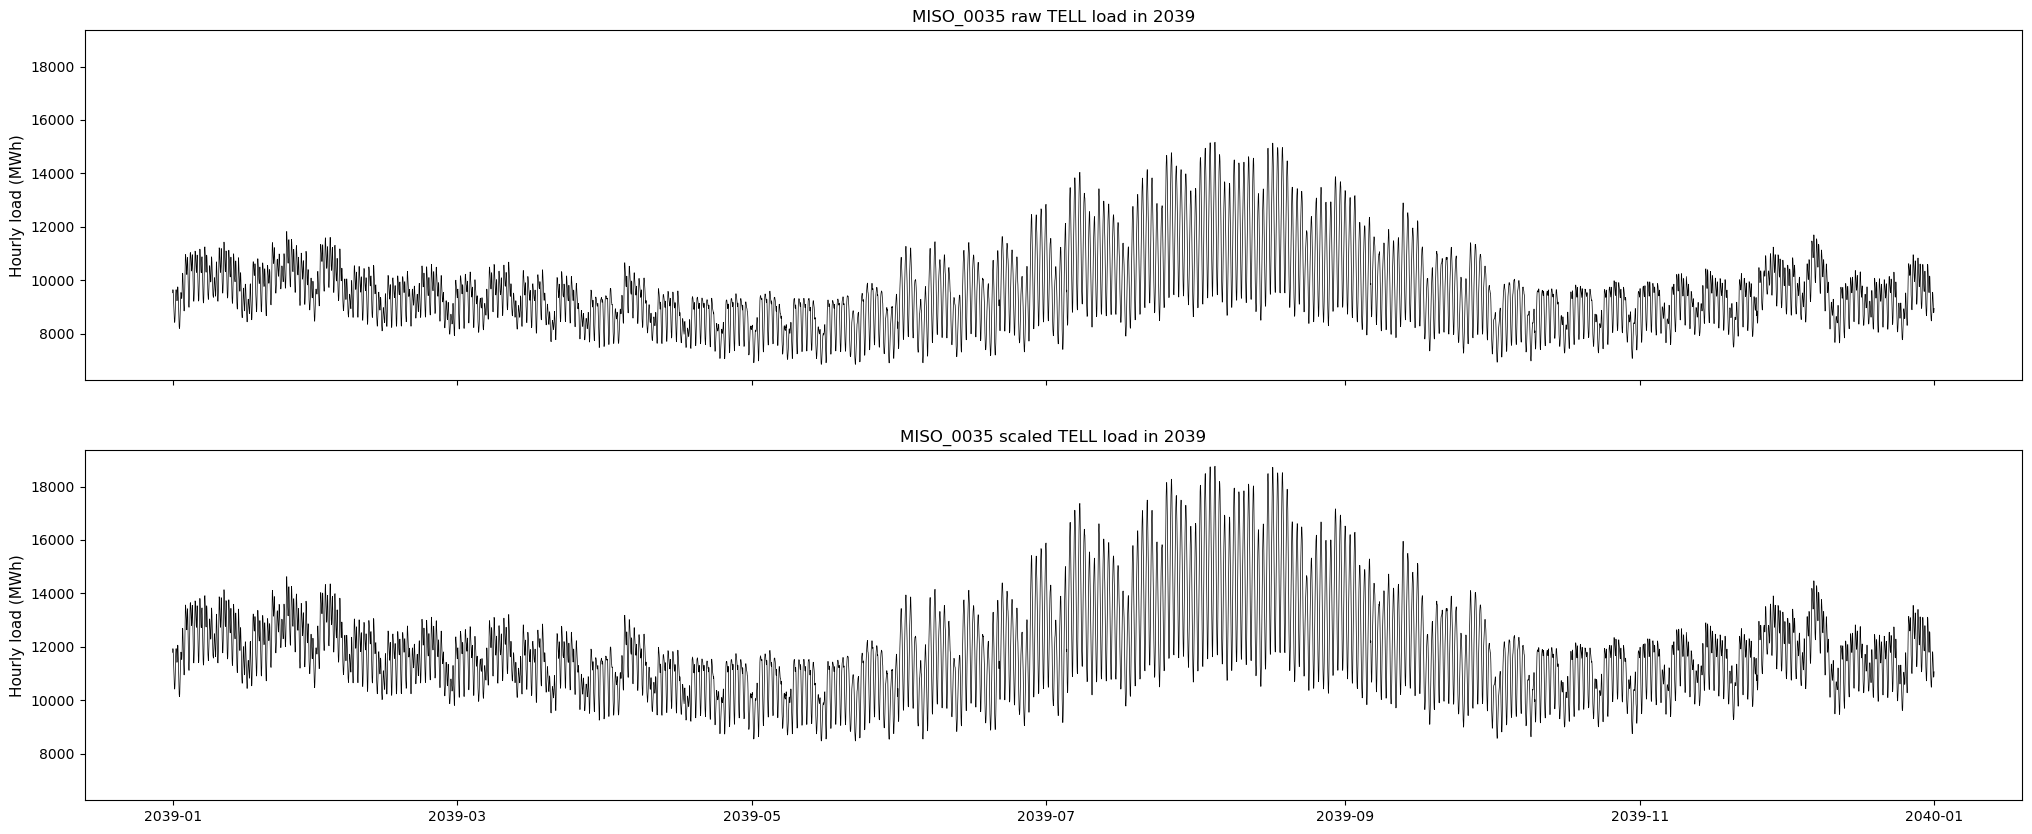

In [14]:
tell.plot_ba_load_time_series(ba_to_plot="MISO_0035", year_to_plot=year_to_process, gcam_target_year=gcam_target_year, scenario_to_plot=scenario_to_process, data_input_dir=tell_data_dir, image_output_dir=tell_image_dir, image_resolution=150, save_images=False)

for ax in plt.gcf().axes:
    ax.set_title(ax.get_title().replace(" Raw TELL Loads in ", " raw TELL load in ").replace(" Scaled TELL Loads in ", " scaled TELL load in "), fontsize=12)
    ax.set_ylabel("Hourly load (MWh)")
plt.show()

## Step 5: Compare Iowa annual load cases

The TELL example above shows one year and one GCAM case. This final section returns to the packaged Iowa state-load Parquet and plots the full 2000-2099 annual load trajectories for raw plus all 8 GCAM-scaled cases.

This is the handoff to downstream notebooks: state scenario metrics and load-growth planning consume these load columns directly.

In [15]:
calendar_year = packaged_load_df["time_utc"].dt.year.rename("year")

expected_years = set(range(2000, 2100))
actual_years = set(calendar_year.unique())
if actual_years != expected_years:
    raise AssertionError(f'Expected complete 2000-2099 Iowa load coverage; missing={sorted(expected_years - actual_years)}, extra={sorted(actual_years - expected_years)}')

load_case_columns = [column for column in packaged_load_df.columns if column.startswith("load_mw__")]
annual_load = packaged_load_df.groupby(calendar_year)[load_case_columns].sum()
annual_load = annual_load.reset_index()
annual_load = annual_load.melt(id_vars="year", var_name="load_case", value_name="annual_load_twh")
annual_load["annual_load_twh"] = annual_load["annual_load_twh"] / 1_000_000.0
annual_load["load_case"] = annual_load["load_case"].str.replace("load_mw__", "", regex=False)

load_case_order = [
    "raw",
    "gcam_rcp45cooler_ssp3",
    "gcam_rcp45cooler_ssp5",
    "gcam_rcp45hotter_ssp3",
    "gcam_rcp45hotter_ssp5",
    "gcam_rcp85cooler_ssp3",
    "gcam_rcp85cooler_ssp5",
    "gcam_rcp85hotter_ssp3",
    "gcam_rcp85hotter_ssp5",
]
missing_cases = set(load_case_order) - set(annual_load["load_case"])
if missing_cases:
    raise AssertionError(f"Missing load case(s): {sorted(missing_cases)}")
extra_cases = set(annual_load["load_case"]) - set(load_case_order)
if extra_cases:
    raise AssertionError(f"Unexpected load case(s): {sorted(extra_cases)}")

### Display: Annual load cases

In [16]:
print(f"Annual Iowa load in {year_to_process}: all nine load cases")
# Labels affect the table and legend only; archive column names stay unchanged.
load_case_labels = {"raw": "Raw"}
for case in load_case_order:
    if case == "raw":
        continue
    label = case.removeprefix("gcam_")
    label = label.replace("rcp45", "RCP4.5 ")
    label = label.replace("rcp85", "RCP8.5 ")
    label = label.replace("_ssp", " / SSP")
    load_case_labels[case] = label
preview = annual_load
preview = preview.loc[annual_load["year"].eq(int(year_to_process))]
preview = preview.replace({"load_case": load_case_labels})
preview = preview.rename(columns={"year": "Year", "load_case": "Load case", "annual_load_twh": "Annual load (TWh)"})
preview = preview.style.hide(axis="index")
preview = preview.format({"Year": "{:.0f}", "Annual load (TWh)": "{:,.3f}"})
display(preview)

Annual Iowa load in 2039: all nine load cases


Year,Load case,Annual load (TWh)
2039,Raw,50.454
2039,RCP4.5 cooler / SSP3,56.842
2039,RCP4.5 cooler / SSP5,71.937
2039,RCP4.5 hotter / SSP3,56.996
2039,RCP4.5 hotter / SSP5,72.041
2039,RCP8.5 cooler / SSP3,56.163
2039,RCP8.5 cooler / SSP5,64.265
2039,RCP8.5 hotter / SSP3,56.139
2039,RCP8.5 hotter / SSP5,64.804


### Plot all 2000-2099 annual load cases


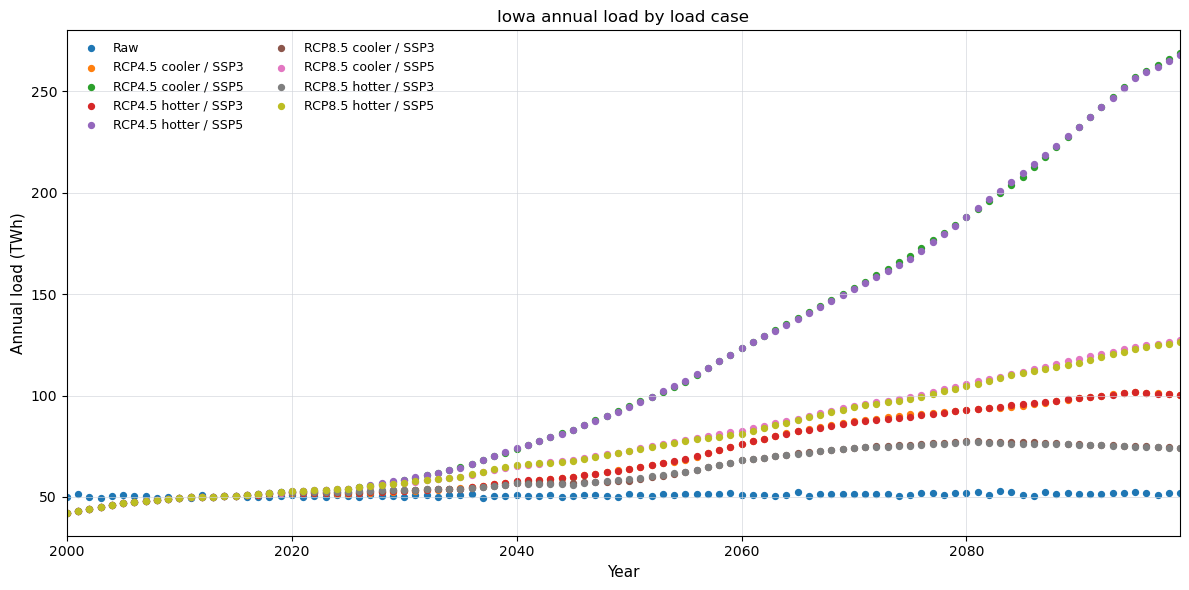

Wrote plot: ../../data_outputs/data_flow/state_load_generation/tell_data/visualizations/IA_2000_2099_annual_load_cases_scatter.png


In [17]:
fig, ax = plt.subplots(figsize=(12, 6))
for load_case in load_case_order:
    case_rows = annual_load[annual_load["load_case"].eq(load_case)]
    ax.scatter(case_rows["year"], case_rows["annual_load_twh"], s=18, label=load_case_labels[load_case])

ax.set_title(f"{STATE_NAME} annual load by load case")
ax.set_xlabel("Year")
ax.set_ylabel("Annual load (TWh)")
ax.set_xlim(2000, 2099)
ax.grid(color="#d1d5db", linewidth=0.7, alpha=0.65)
ax.legend(ncol=2)
fig.tight_layout()

load_case_plot_path = tell_image_dir / "IA_2000_2099_annual_load_cases_scatter.png"
fig.savefig(load_case_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Wrote plot: {Path(os.path.relpath(load_case_plot_path)).as_posix()}")

## Interpretation

The worked reconstruction checks Iowa hourly load for one year and one GCAM case against the archive, using the stated rounding tolerance. The final annual plot reads the archived raw and eight GCAM-scaled load cases for 2000-2099; it does not reconstruct all nine trajectories. County allocation uses fixed 2020 population, while GCAM scaling changes annual demand.
